# Etape de modilisation:


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
## import des librairie necessaires :

import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from imblearn.metrics import classification_report_imbalanced, geometric_mean_score
from sklearn.metrics import f1_score
import pandas as pd
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from skopt import BayesSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from google.colab import drive
drive.mount('/content/drive')

##librairie DEEP LEARNING
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Activation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **`Classification Milti-classe supervisée avec segmentation et Extraction de feature`**

###### **`Segmentation:`**

Pour chaque catégorie du jeu de données MVTec, une analyse visuelle a permis d’identifier la nature dominante des défauts. Les défauts chromatiques ont été traités par une segmentation basée sur la couleur, tandis que les défauts structurels ont été traités par une segmentation basée sur les contours. Lorsque les défauts sont internes ou purement texturels, aucune segmentation n’a été appliquée.

| Catégorie MVTec | Type de catégorie | Type dominant de défaut         | Segmentation recommandée |
| --------------- | ----------------- | ------------------------------- | ------------------------ |
| **carpet**      | Texture           | Texture / couleur diffuse       | **Couleur**              |
| **grid**        | Texture           | Structure (lignes cassées)      | **Contours**             |
| **leather**     | Texture           | Couleur / texture               | **Couleur**              |
| **tile**        | Texture           | Couleur / motif                 | **Couleur**              |
| **wood**        | Texture           | Couleur / texture               | **Couleur**              |
| **bottle**      | Objet             | Texture interne / contamination | **Aucune**               |
| **cable**       | Objet             | Structure / coupure             | **Contours**             |
| **capsule**     | Objet             | Couleur / texture               | **Couleur**              |
| **hazelnut**    | Objet             | Couleur (zones brunies)         | **Couleur**              |
| **metal_nut**   | Objet             | Forme / géométrie               | **Contours**             |
| **pill**        | Objet             | Couleur / surface               | **Couleur**              |
| **screw**       | Objet             | Forme / orientation             | **Contours**             |
| **toothbrush**  | Objet             | Forme / structure               | **Contours**             |
| **transistor**  | Objet             | Structure / composants          | **Contours**             |
| **zipper**      | Objet             | Structure (dents manquantes)    | **Contours**             |


Cette fonction réalise une segmentation par couleur.
Son but est de conserver uniquement les zones colorées de l’image et de supprimer les zones peu colorées (blanc, gris, noir, ombres).


La segmentation repose sur la saturation des couleurs :

Une couleur “forte” → saturation élevée

Une couleur “fade”, gris ou blanc → saturation faible

On utilise donc la composante S (Saturation) pour décider quels pixels garder.

In [ ]:
def segment_color_simple(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    mask = (s > 30).astype("uint8") * 255
    return cv2.bitwise_and(img, img, mask=mask)


Cette fonction réalise une segmentation basée sur les contours.
Son but est de :

* Détecter l’objet principal dans l’image
* Découper l’image pour ne garder que la zone de cet objet

In [ ]:
def segment_contour_simple(img):
    # Si l'image est déjà en niveaux de gris
    if img.ndim == 2:
        gray = img
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    edges = cv2.Canny(gray, 50, 150)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    return img[y:y+h, x:x+w]

In [ ]:
SEGMENTATION_BY_CATEGORY = {
    "grid": "none",
    "cable": "contour",
    "screw": "contour",
    "zipper": "contour",
    "metal_nut": "contour",

    "wood": "color",
    "leather": "color",
    "tile": "color",
    "carpet": "color",
    "pill": "color",
    "hazelnut": "color",
    "capsule": "color",

    "bottle": "none",
}


In [ ]:
##choisir la segmentation à appliquer

def apply_segmentation(img, category):
    mode = SEGMENTATION_BY_CATEGORY.get(category, "none")

    if mode == "contour":
        return segment_contour_simple(img)

    elif mode == "color":
        return segment_color_simple(img)

    else:  # "none"
        return img


**Justification des choix de segmentation par categorie:**

| Catégorie      | Type    | Segmentation choisie | Pourquoi ce choix est pertinent                                                                                                                                                                |
| -------------- | ------- | -------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **carpet**     | Texture | Couleur              | Les défauts apparaissent comme des variations chromatiques et de texture réparties sur la surface. La segmentation couleur permet d’isoler les zones anormales et de réduire le bruit du fond. |
| **grid**       | Texture | Contours             | Les défauts se traduisent par des ruptures de lignes et des discontinuités structurelles. La segmentation par contours met en évidence ces anomalies géométriques.                             |
| **leather**    | Texture | Couleur              | Les défauts correspondent principalement à des décolorations et des irrégularités de surface visibles par la couleur.                                                                          |
| **tile**       | Texture | Couleur              | Les anomalies modifient les motifs et la teinte des carreaux. La segmentation couleur permet de détecter ces différences chromatiques.                                                         |
| **wood**       | Texture | Couleur              | Les défauts (taches, brûlures) sont principalement de nature chromatique et se distinguent par la couleur.                                                                                     |
| **bottle**     | Objet   | Aucune               | L’objet est centré sur fond uniforme et les défauts sont internes. Une segmentation pourrait supprimer des informations utiles.                                                                |
| **cable**      | Objet   | Contours             | Les défauts affectent la structure du câble (coupures, déformations). La segmentation par contours permet d’isoler la forme.                                                                   |
| **capsule**    | Objet   | Couleur              | Les défauts se manifestent par des variations de couleur et de texture sur la surface.                                                                                                         |
| **hazelnut**   | Objet   | Couleur              | Les anomalies sont visibles sous forme de zones brunies ou décolorées, donc chromatiques.                                                                                                      |
| **metal_nut**  | Objet   | Contours             | Les défauts modifient la géométrie et les arêtes de l’objet métallique. Les contours sont discriminants.                                                                                       |
| **pill**       | Objet   | Couleur              | Les anomalies correspondent à des différences de teinte et d’aspect de surface.                                                                                                                |
| **screw**      | Objet   | Contours             | Les défauts entraînent des déformations de la vis, visibles au niveau de la forme et des bords.                                                                                                |
| **toothbrush** | Objet   | Contours             | Les anomalies affectent la structure et l’alignement de l’objet.                                                                                                                               |
| **transistor** | Objet   | Contours             | Les défauts sont liés à la disposition et à la forme des composants.                                                                                                                           |
| **zipper**     | Objet   | Contours             | Les anomalies se manifestent par des dents manquantes ou mal alignées, donc structurelles.                                                                                                     |


###### **`Appliquer une extraction de feature :`**

La règle de base (débutant)

Pour un type d’objet, on choisit l’extraction de features selon la propriété la plus stable et la plus discriminante :

* Couleur / teinte dominante → extract_color_features (histogrammes HSV)

* Texture / motif répétitif → extract_lbp_features (LBP)

* Forme / bords / structure → extract_hog_features (HOG)

L’objectif est d’avoir un vecteur qui sépare bien “normal” vs “anormal” pour cet objet, sans être trop sensible aux variations inutiles (luminosité, petits décalages, etc.).

1) Pourquoi choisir les features couleur (HSV histogrammes) ?
Quand c’est pertinent

Matériaux avec couleur/teinte caractéristique : wood, leather, tile, carpet, pill, hazelnut, capsule…

Quand les anomalies changent souvent :

* la teinte (H)

* la saturation (S) (tache, décoloration, zone “fade”)

Pourquoi HSV (H & S)

* H capture “quelle couleur”

* S capture “à quel point c’est coloré”

* Ça évite de trop dépendre de la luminosité (V) → plus robuste.

En résumé : si l’objet se reconnaît surtout par sa couleur / matière colorée, l’histogramme HSV est un bon choix.

In [ ]:
def extract_color_features(img, bins=16):
    """
    Histogrammes couleur simples (HSV).
    Retourne un vecteur 1D normalisé.
    """
    # Si image en gris = pas de couleur
    if img.ndim == 2:
        return np.zeros(bins * 2, dtype=np.float32)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    hist_h = cv2.calcHist([hsv], [0], None, [bins], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [bins], [0, 256])

    hist = np.concatenate([hist_h, hist_s]).flatten()
    hist = hist / (hist.sum() + 1e-8)

    return hist.astype(np.float32)


2) Pourquoi choisir les features texture (LBP) ?
Quand c’est pertinent

Surfaces avec motifs et micro-textures :

* carpet, tile, leather, wood (souvent)

Anomalies typiques :

* rayures fines

* trous

* zones rugueuses / lisses anormales

* changements locaux de texture

Pourquoi LBP

LBP compare chaque pixel à ses voisins → il décrit des patterns locaux (grain, rugosité) et fait un histogramme global.

En résumé : si le “grain” ou le motif du matériau est l’information la plus importante, LBP est souvent plus discriminant que la couleur.

In [ ]:
def extract_lbp_features(img):
    """
    LBP simple (8 voisins) + histogramme.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = gray.astype(np.uint8)
    h, w = gray.shape

    lbp = np.zeros((h, w), dtype=np.uint8)

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            center = gray[y, x]
            code = 0
            code |= (gray[y-1, x-1] >= center) << 7
            code |= (gray[y-1, x  ] >= center) << 6
            code |= (gray[y-1, x+1] >= center) << 5
            code |= (gray[y,   x+1] >= center) << 4
            code |= (gray[y+1, x+1] >= center) << 3
            code |= (gray[y+1, x  ] >= center) << 2
            code |= (gray[y+1, x-1] >= center) << 1
            code |= (gray[y,   x-1] >= center) << 0
            lbp[y, x] = code

    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + 1e-8)

    return hist


3) Pourquoi choisir les features forme/bords (HOG) ?
Quand c’est pertinent

Objets où la géométrie et les bords dominent :

screw, cable, zipper, grid, metal_nut…

Anomalies typiques :

* déformation de forme

* pièce manquante / cassée

* mauvais alignement / partie tordue

* contour anormal

Pourquoi HOG

HOG résume les orientations de gradients (les directions des bords) sur des cellules → excellent pour décrire structure + forme, même si la couleur change peu.

En résumé : si l’objet est surtout “une forme” avec des contours nets, HOG est généralement plus adapté que la couleur.

In [ ]:
def extract_hog_features(img):
    """
    HOG simple avec OpenCV.
    """
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    gray = cv2.resize(gray, (128, 128))

    hog = cv2.HOGDescriptor(
        _winSize=(128, 128),
        _blockSize=(16, 16),
        _blockStride=(8, 8),
        _cellSize=(8, 8),
        _nbins=9
    )

    features = hog.compute(gray)
    return features.flatten().astype(np.float32)


In [ ]:
def extract_features(img, category):
    features = []

    if category in ["wood", "leather", "tile", "carpet", "pill", "hazelnut", "capsule"]:
        features.append(extract_color_features(img))
        features.append(extract_lbp_features(img))

    elif category in ["grid", "cable", "screw", "zipper", "metal_nut",
                      "toothbrush", "transistor"]:
        features.append(extract_hog_features(img))

    elif category == "bottle":
        features.append(extract_lbp_features(img))
        features.append(extract_hog_features(img))

    else:
        features.append(extract_lbp_features(img))

    return np.concatenate(features)


Dans le tableau ci-dessous nous avons detaillé et justifier les choix des extraction de feature utilisé pour chaque categorie:

| Catégorie      | Type (Texture / Objet) | Type dominant de défaut         | Segmentation choisie | Features recommandées | Justification                                               |
| -------------- | ---------------------- | ------------------------------- | -------------------- | --------------------- | ----------------------------------------------------------- |
| **carpet**     | Texture                | Texture / couleur diffuse       | Couleur              | Couleur + LBP         | Défauts visibles par variations chromatiques et texturelles |
| **grid**       | Texture                | Structure (lignes cassées)      | Contours             | HOG                   | Les anomalies sont des ruptures géométriques                |
| **leather**    | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Défauts visibles par décoloration et texture                |
| **tile**       | Texture                | Motif / couleur                 | Couleur              | Couleur + LBP         | Changements de motif et de teinte                           |
| **wood**       | Texture                | Couleur / texture               | Couleur              | Couleur + LBP         | Taches et brûlures chromatiques                             |
| **bottle**     | Objet                  | Texture interne / contamination | Aucune               | LBP + HOG             | Défauts internes détectables par texture                    |
| **cable**      | Objet                  | Structure / coupure             | Contours             | HOG                   | Défauts de forme et de continuité                           |
| **capsule**    | Objet                  | Couleur / texture               | Couleur              | Couleur + LBP         | Variations chromatiques de surface                          |
| **hazelnut**   | Objet                  | Couleur (zones brunies)         | Couleur              | Couleur + LBP         | Anomalies visibles par la teinte                            |
| **metal_nut**  | Objet                  | Géométrie / arêtes              | Contours             | HOG                   | Défauts affectant la forme                                  |
| **pill**       | Objet                  | Couleur / surface               | Couleur              | Couleur + LBP         | Défauts chromatiques et texturels                           |
| **screw**      | Objet                  | Forme / orientation             | Contours             | HOG                   | Déformations de la vis                                      |
| **toothbrush** | Objet                  | Structure                       | Contours             | HOG                   | Défauts géométriques                                        |
| **transistor** | Objet                  | Structure / composants          | Contours             | HOG                   | Disposition anormale des composants                         |
| **zipper**     | Objet                  | Structure (dents manquantes)    | Contours             | HOG                   | Ruptures dans la structure des dents                        |


###### **`Appliquer les preprocissing et création de X et y à partir des données de train et test :`**

In [ ]:
## préprocessing: Création des dossiers X et y avec les données train et test melangé dans X et les labels dans y:
## Fonction qui permet de faire les preprocessing necessaires:

def Dataset_supervise (path, category):

    """ fonction qui permet de regrouper


              """

    ## stocker les images prétraité:
    img_prp= []
    ##lire tout les images:
    img_paths = glob(os.path.join(path, "**", "*.*"), recursive=True)

    ## afficher le nombre d'image trouver par categorie:
    print(f"Nombre d'images trouvées dans {category} : {len(img_paths)}")



    ## Lire les images sans les convertir en gris
    for file_path in img_paths:
      img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)
      if img is None:
        continue
      if img.ndim == 3 and img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)



      ##redimentionnement des taille:
      img=cv2.resize(img, (256,256))


      # SEGMENTATION: ajouter une condition pour lancer lensembel des categorie
      img = apply_segmentation(img, category)

      # remettre à taille fixe après segmentation
      img = cv2.resize(img, (256, 256))

      #EXTRACTION DE FEATURES
      feature = extract_features(img, category)


      ##ajouter le resultats dans la liste :
      img_prp.append(img)



    ##convertir la liste en tableau numpy:
    X = np.array(img_prp)


    return X





###### **`Création des données train et test pour la classification multi-classe :`**

In [ ]:
# Mapping explicite des anomalies
label_map = {
    "good": 0,
    "broken": 1,
    "metal_contamination": 2,
    "glue": 3,
    "thread": 4,
    "bent": 5
}


In [ ]:
# GOOD (label 0)
path_good = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good"

X_train_list, y_train_list = [], []

X_good = Dataset_supervise(path_good, category="grid", do_augment=True, k=3)
y_good = np.full(len(X_good), label_map["good"], dtype=np.int64)

X_train_list.append(X_good)
y_train_list.append(y_good)

# ANOMALIES (labels par type)
path_anom_train = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test"
anom_defect_dirs = [d for d in glob(os.path.join(path_anom_train, "*")) if os.path.isdir(d)]

for defect_dir in anom_defect_dirs:
    defect_name = os.path.basename(defect_dir)

    if defect_name not in label_map:
        print(f"Défaut ignoré : {defect_name}")
        continue

    label = label_map[defect_name]

    X_anom = Dataset_supervise(defect_dir, category="grid", do_augment=True, k=30)
    y_anom = np.full(len(X_anom), label, dtype=np.int64)

    X_train_list.append(X_anom)
    y_train_list.append(y_anom)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Distribution labels:", np.unique(y_train, return_counts=True))


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/good/grid : 264
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/thread/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/bent/grid : 7
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/anomaly_from_test/metal_contamination/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/train/ano

In [ ]:
X_test_list = []
y_test_list = []

path = "/content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection"
categories = glob(path + "/grid")


for cat in categories:
    category = os.path.basename(cat)
    test_path = os.path.join(cat, "test")
    if not os.path.exists(test_path):
        continue

    # GOOD → label 0
    good_path = os.path.join(test_path, "good")
    if os.path.exists(good_path):
        X_good = Dataset_supervise(good_path, category, do_augment=False, k=1)
        y_good = np.full(len(X_good), label_map["good"], dtype=np.int64)
        X_test_list.append(X_good)
        y_test_list.append(y_good)

    # ANOMALIES: label selon le dossier
    for anomaly in os.listdir(test_path):
        if anomaly == "good":
            continue

        if anomaly not in label_map:
            print(f"Dossier anomalie inconnu ignoré : {anomaly}")
            continue

        anomaly_path = os.path.join(test_path, anomaly)
        if os.path.isdir(anomaly_path):
            X_anom = Dataset_supervise(anomaly_path, category, do_augment=False, k=1)
            y_anom = np.full(len(X_anom), label_map[anomaly], dtype=np.int64)

            X_test_list.append(X_anom)
            y_test_list.append(y_anom)

X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Distribution test:", np.unique(y_test, return_counts=True))


Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/good/grid : 21
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/broken/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/glue/grid : 6
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/bent/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/metal_contamination/grid : 5
Nombre d'images trouvées dans /content/drive/MyDrive/Fomation_Data_Scientist/Projet_Detection_Anomalies/mvtec_anomaly_detection/grid/test/thread/grid : 5
X_test: (48, 256, 256, 3)
y_test: (48,)
Distribution test: (array([0

In [ ]:
##fusion des données test avec train pour créer les dossier X et y:
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_testt], axis=0)

print(X_.shape, y.shape)


##spliter en données d'entrainnement et de test on laissant 20% pour les données test:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
##normalisation
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

## reshape pour ajouter le canal
#X_train = X_train.reshape(-1, 256, 256, 1)
#X_test  = X_test.reshape(-1, 256, 256, 1)

In [ ]:
##creation des données de valisation et de train à partir de X_train et y_train

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(X_tr.shape, X_val.shape, y_tr.shape, y_val.shape)
print("Distrib train:", np.unique(y_tr, return_counts=True))
print("Distrib val:", np.unique(y_val, return_counts=True))

(1588, 256, 256, 3) (398, 256, 256, 3) (1588,) (398,)
Distrib train: (array([0, 1, 2, 3, 4, 5]), array([844, 149, 149, 124, 149, 173]))
Distrib val: (array([0, 1, 2, 3, 4, 5]), array([212,  37,  37,  31,  37,  44]))


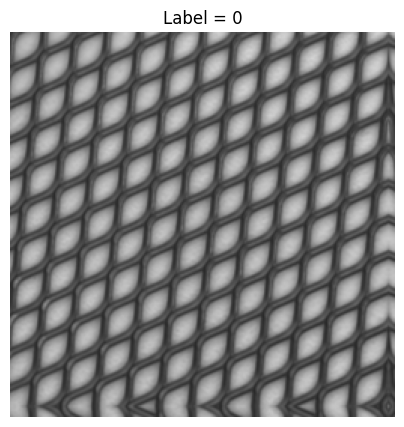

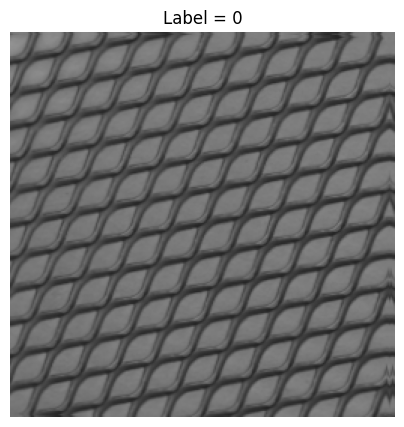

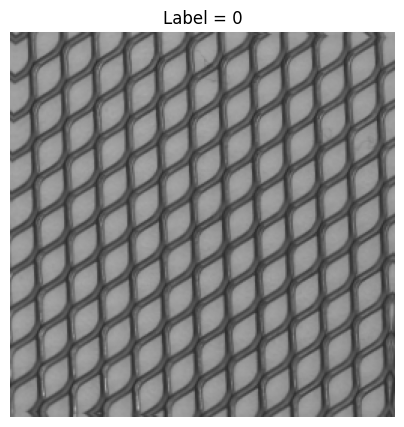

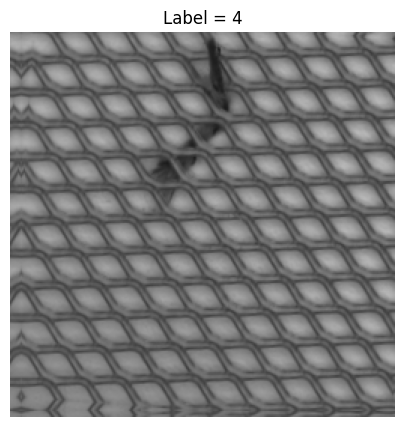

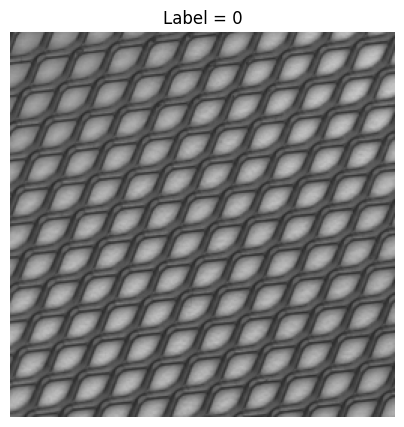

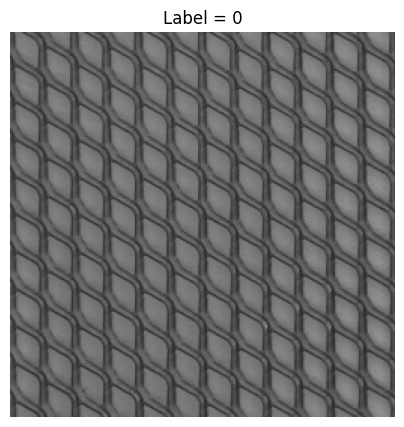

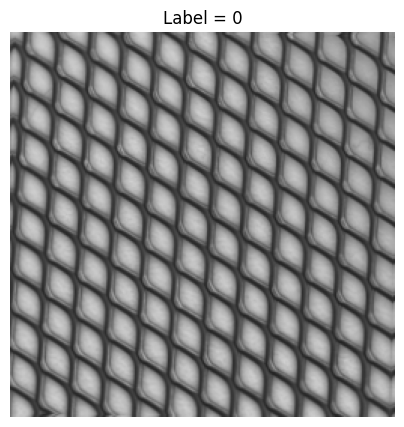

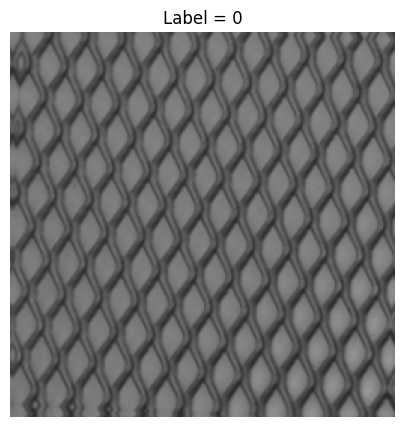

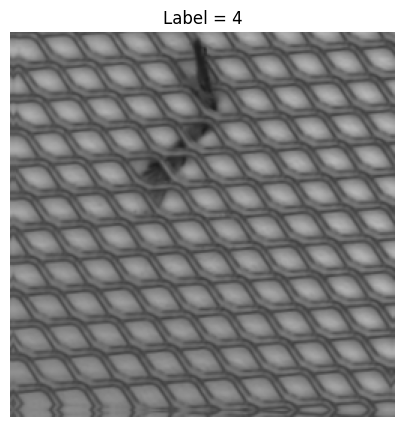

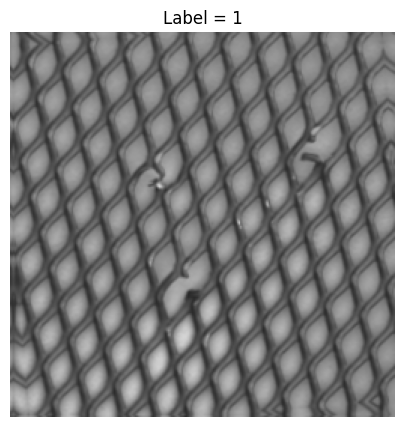

In [ ]:
##Affiche quelques images avec leur label pour voir si on a bien les bon label pour les bonnes images

for i in range(10):
    plt.figure(figsize=(5,5))

    plt.imshow(X_tr[i].squeeze(), cmap="gray")
    plt.title(f"Label = {y_tr[i]}")
    plt.axis("off")
    plt.show()


###### **`Instanciation du modele:`**

In [ ]:
print(np.unique(y_tr))
print(np.unique(y_val))

[0 1 2 3 4 5]
[0 1 2 3 4 5]


In [ ]:
# Entrée
inputs = Input(shape=(256, 256, 3), name="input_image")

# conv1
x = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x = MaxPooling2D((2, 2))(x)

#conv 2
x = Conv2D(64, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Bloc conv 3
x = Conv2D(128, (3, 3), padding="same", activation="relu")(x)
x = MaxPooling2D((2, 2))(x)

# Applatir pour les utiliser dans dense
x = GlobalAveragePooling2D()(x)

# Couche Dense 1
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
# Couche Dense 7
outputs = Dense(6, activation="softmax", name="output")(x)





# Modèle
model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
## Ajout de callbak pour stopper le modele si la val_loss stagne
early_stopping= EarlyStopping(patience=5, min_delta=0.001,verbose=1, mode='min',monitor= "val_loss")

reduceLR= ReduceLROnPlateau( monitor= "val_loss",patience=3, min_delta=0.01, factor=0.1, mode='min',verbose=1,cooldown=4)


In [ ]:
#### entrainnement du modele  en utilisant epochs=10, batch_size=32 et on laisse 20% pour les données de validation:

history = model.fit(X_tr, y_tr, epochs=15, batch_size=32,  validation_data=( X_val, y_val) ,callbacks=[reduceLR, early_stopping])


Epoch 1/15
20/50 ━━━━━━━━━━━━━━━━━━━━ 1:30 3s/step - accuracy: 0.4346 - loss: 1.6427

In [ ]:
## afficher la coube de l'evolution de la fonction de la perte loss et celle de Val_loss:

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')


plt.title('Courbes de loss et val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print(f"Accuracy : {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred): .2f}")
print(f"F1-score: {f1_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")